# DQN with Double Q-Learning (Double DQN)

Standard Deep Q-Networks suffer from overestimation bias because target calculations use a maximum over predicted values ($\max_{a'} Q(s', a'; \theta^-)$). **Double DQN** decouples the action selection from action evaluation:
1. Use the online network $\theta$ to select the best action: $a^* = \arg\max_a Q(s', a; \theta)$.
2. Use the target network $\theta^-$ to evaluate that action: $Q(s', a^*; \theta^-)$.
This notebook implements Double DQN in PyTorch on a synthetic state space, training it for 80 steps, and visualizes the loss decay.



In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define a simple replay buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.pos = 0
        
    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        self.pos = (self.pos + 1) % self.capacity
        
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

# Initialize standard buffer
replay_buffer = ReplayBuffer(capacity=1000)



## Neural Q-Network Architecture

We implement the state-to-action value MLP model.



In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim)
        )
        
    def forward(self, x):
        return self.fc(x)

online_net = QNetwork()
target_net = QNetwork()
target_net.load_state_dict(online_net.state_dict())
optimizer = optim.Adam(online_net.parameters(), lr=0.005)



## Double DQN Pipeline Optimization

We populate the buffer with dummy experiences and train the online network for 80 steps using Double Q-learning updates.



In [3]:
# Populate buffer
for _ in range(200):
    s = np.random.normal(0, 0.5, 4)
    a = random.randint(0, 1)
    r = np.random.uniform(-1, 1)
    ns = np.random.normal(0, 0.5, 4)
    d = random.choice([True, False])
    replay_buffer.push(s, a, r, ns, d)

epochs = 80
batch_size = 32
gamma = 0.99
losses = []

for step in range(epochs):
    # Sample transitions
    samples = replay_buffer.sample(batch_size)
    
    states = torch.FloatTensor(np.array([x[0] for x in samples]))
    actions = torch.LongTensor(np.array([x[1] for x in samples]))
    rewards = torch.FloatTensor(np.array([x[2] for x in samples]))
    next_states = torch.FloatTensor(np.array([x[3] for x in samples]))
    dones = torch.FloatTensor(np.array([x[4] for x in samples]))
    
    # Current state-action Q values from online network
    q_values = online_net(states)
    state_action_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    
    # Double DQN update:
    # 1. Action selection using ONLINE network
    with torch.no_grad():
        next_online_q = online_net(next_states)
        best_actions = next_online_q.max(1)[1] # Argmax_a Q(s', a; theta_online)
        
        # 2. Action evaluation using TARGET network
        next_target_q = target_net(next_states)
        evaluate_target_q = next_target_q.gather(1, best_actions.unsqueeze(1)).squeeze(1)
        
        expected_values = rewards + gamma * evaluate_target_q * (1.0 - dones)
        
    loss = nn.functional.mse_loss(state_action_values, expected_values)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    # Periodically sync target network
    if step % 10 == 0:
        target_net.load_state_dict(online_net.state_dict())
        
    if (step + 1) % 20 == 0:
         print(f"Step {step+1:2d}/{epochs} | Double DQN MSE Loss: {loss.item():.4f}")



Step 20/80 | Double DQN MSE Loss: 0.3305
Step 40/80 | Double DQN MSE Loss: 0.2730
Step 60/80 | Double DQN MSE Loss: 0.3250
Step 80/80 | Double DQN MSE Loss: 0.2998


## Loss Convergence Curve

We visualize the training MSE loss progression in Matplotlib.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



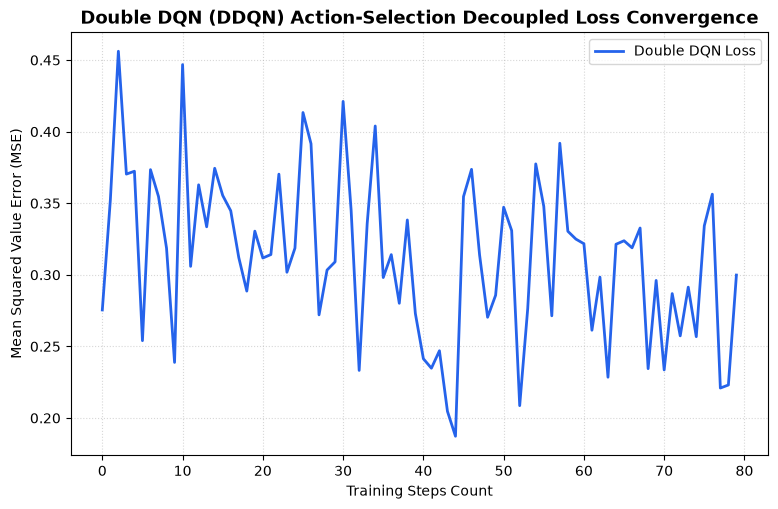

In [4]:
plt.figure(figsize=(9, 5.5))
plt.plot(losses, color='#2563EB', linewidth=2.0, label='Double DQN Loss')

plt.title('Double DQN (DDQN) Action-Selection Decoupled Loss Convergence', fontsize=13, fontweight='bold')
plt.xlabel('Training Steps Count')
plt.ylabel('Mean Squared Value Error (MSE)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
